In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline
from sklearn import metrics

!pip install imblearn
from imblearn.over_sampling import SMOTE

In [2]:
!wget archive.zip

--2026-04-18 15:05:47--  http://archive.zip/
Resolving archive.zip (archive.zip)... 172.67.187.253, 104.21.7.195, 2606:4700:3037::6815:7c3, ...
Connecting to archive.zip (archive.zip)|172.67.187.253|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://archive.zip/ [following]
--2026-04-18 15:05:47--  https://archive.zip/
Connecting to archive.zip (archive.zip)|172.67.187.253|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘index.html’

index.html              [ <=>                ]      26  --.-KB/s    in 0s      

2026-04-18 15:05:48 (4.04 MB/s) - ‘index.html’ saved [26]



In [3]:
!unzip archive.zip

Archive:  archive.zip
  inflating: Churn_Modelling.csv     


In [4]:
# Ma'lumotlarni o'zgaruvchiga o'qish
df = pd.read_csv('archive.zip')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
# Ma'lumot hajmi
df.shape

(10000, 14)

In [6]:
# Ma'lumotlarni statistik tahlili
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
# Ma'lumotlar to'plami tuzilishi
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [8]:
# Ketgan va qolgan mijozlar foizi (%)
df['Exited'].value_counts()/len(df)*100

,count
Exited,
0,79.63
1,20.37


In [9]:
ch_rate = df['Exited'].value_counts()/len(df)*100

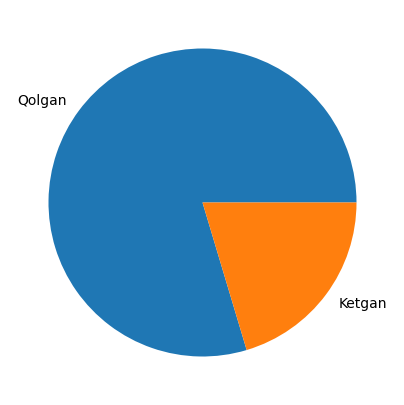

In [ ]:
# Ketgan va qolgan mijozlar grafigda
plt.figure(figsize=(5,5))
plt.pie(ch_rate, labels=['Qolgan', 'Ketgan'])
plt.show()

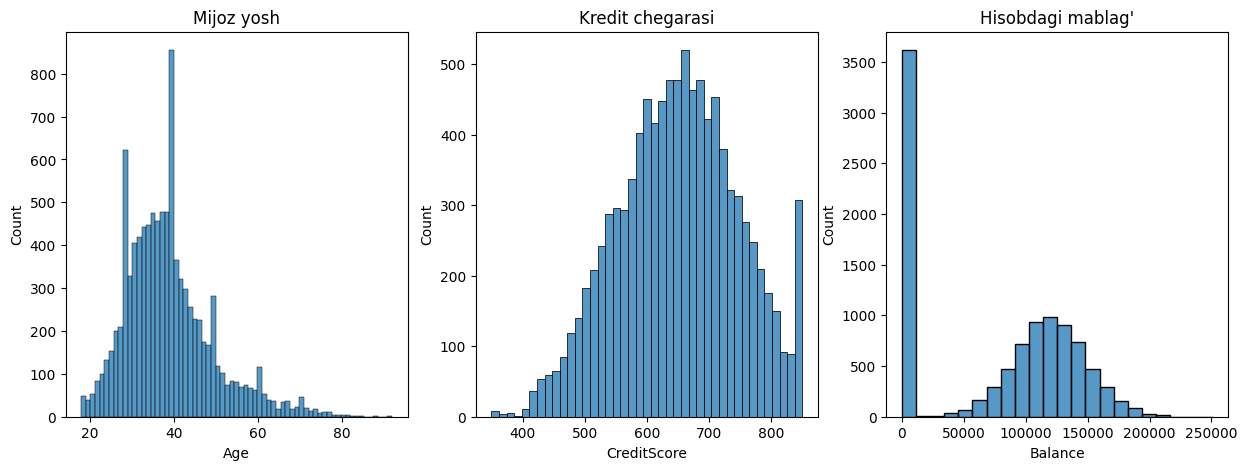

In [10]:
# Ma'lumotlar taqsimoti
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

#Tenure
sns.histplot(df['Age'], ax=axes[0])
axes[0].set_title('Mijoz yosh')

#CreditScore
sns.histplot(df['CreditScore'], ax=axes[1])
axes[1].set_title('Kredit chegarasi')

#Balance
sns.histplot(df['Balance'], ax=axes[2])
axes[2].set_title('Hisobdagi mablag\'')

plt.show()

In [11]:
# Katigorjyali ustun tahlili
plt.figure(figsize=(15,5))
sns.countplot(df['Gender'], ax=axes[0])
axes[0].set_title('Mijoz jinsi')

plt.show()

<Figure size 1500x500 with 0 Axes>

In [12]:
# Kerakmas ustunlarni o'chirib tashlash
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [13]:
#  Matnli ustunlarni songa o'tkazish (LabelEncoder)
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['Geography'] = le.fit_transform(df['Geography'])
df['Surname'] = le.fit_transform(df['Surname'])

In [14]:
# Ustunlar bir biriga qanchalik bog'liqlgini ko'rish
df.corrwith(df['Exited']).abs().sort_values(ascending=False)

,0
Exited,1.000000
Age,0.285323
IsActiveMember,0.156128
Balance,0.118533
Gender,0.106512
NumOfProducts,0.047820
Geography,0.035943
CreditScore,0.027094
RowNumber,0.016571
Tenure,0.014001


In [15]:
# Modelni tayyorlash
X = df.drop('Exited', axis=1)
y = df['Exited']

In [16]:
# Standartlash
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [17]:
# X_train, y_train, X_test, va y_test ga bo'lamiz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
# Ma'lumotlarni muvozanatlashtiramiz
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

smote.fit(X_train_res, y_train_res)

SMOTE(random_state=42)

              precision    recall  f1-score   support

           0       0.92      0.90      0.91      1647
           1       0.59      0.65      0.62       353

    accuracy                           0.86      2000
   macro avg       0.76      0.78      0.77      2000
weighted avg       0.86      0.86      0.86      2000

Model aniqligi: 0.858


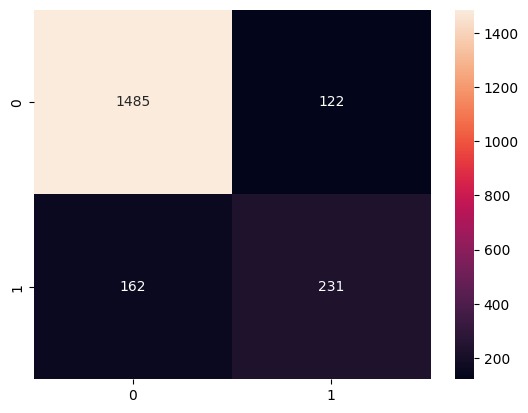

In [35]:
# Modelni tarbiyalaymiz (Random Forest)
RF_model = RandomForestClassifier()
RF_model.fit(X_train, y_train)

# Modelni bashorat qilamiz
y_pred = RF_model.predict(X_test)
print(metrics.classification_report(y_pred, y_test))
print("Model aniqligi:", metrics.accuracy_score(y_pred, y_test))

# Confusion matrix
conf = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(conf, annot=True, fmt='d')
plt.show()



              precision    recall  f1-score   support

           0       0.92      0.89      0.91      1661
           1       0.54      0.63      0.58       339

    accuracy                           0.85      2000
   macro avg       0.73      0.76      0.74      2000
weighted avg       0.86      0.85      0.85      2000

Model aniqligi: 0.846


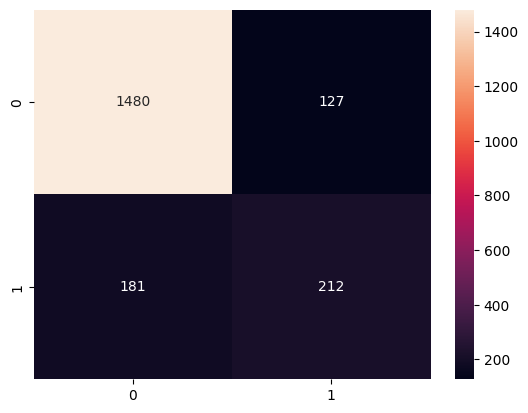

In [36]:
# Modelni tarbiyalaymiz (XGBoost)
XG_model = XGBClassifier()
XG_model.fit(X_train, y_train)

# Bashorat qilamiz
y_pred = XG_model.predict(X_test)
print(metrics.classification_report(y_pred, y_test))
print("Model aniqligi:", metrics.accuracy_score(y_pred, y_test))

# Confusion matrix
conf = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(conf, annot=True, fmt='d')
plt.show()